# Embedding & Finalization Timing Analysis

This notebook helps you **systematically optimize** your Celery and LiteLLM settings for embedding operations.

## Workflow:

1. **Configure** your Azure TPM, Celery concurrency, and LiteLLM settings at the top
2. **Run baseline tests** (mock vs real) to understand API overhead
3. **Iterate experiments** with different concurrency levels
4. **Track results** automatically across all runs
5. **Visualize performance** to find the optimal "sweet spot"
6. **Calculate optimal formula** for production use

## Key Metrics:

- **Throughput** (chunks/sec): How fast you process embeddings
- **Rate limiting**: Whether you hit 429 errors
- **Efficiency**: Throughput per worker
- **API overhead**: Time spent waiting for API vs processing

## Goal:

Find the optimal `celery_concurrency` and `litellm_max_parallel_requests` values based on your `AZURE_TPM` limit that:
- Maximizes throughput without hitting rate limits
- Efficiently uses resources
- Can be expressed as a formula for different Azure TPM values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import subprocess
import time
from pathlib import Path
import json

# Set up plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# File paths - base on directory of this file
SCRIPT_PATH = '/workspace/django/tests/misc_non_pytest/finalize_timing_test.py'
LOG_PATH = '/workspace/django/tests/misc_non_pytest/librarian_embedding_log.csv'
EXPERIMENTS_LOG = '/workspace/django/tests/misc_non_pytest/concurrency_experiments.csv'

## Stop All Active Tasks (Optional)

Run this command if you want to clear all tasks from the Celery queues before starting a new test run. This ensures you're starting from a clean slate.

In [51]:
# This command will stop and remove all tasks currently in the queue.
# The -f flag forces it to not ask for confirmation.
# This command will stop and remove all tasks currently in the queue.
# The -f flag forces it to not ask for confirmation.
%cd /workspace/django
!celery -A otto purge -f

/workspace/django
Using .env.example
Running in debug mode: True
No messages purged from 1 queue.


## Helper Functions

## Experiment Configuration

Configure your current test parameters here. These will be used to:
1. Calculate theoretical optimal settings
2. Track results across multiple experiments
3. Compare actual vs theoretical performance

In [84]:
# ============================================================================
# EXPERIMENT CONFIGURATION - Update these before each test run
# ============================================================================

# Azure OpenAI Configuration
AZURE_TPM = 950_000  # Azure Tokens Per Minute rate limit (adjust as needed)
                     # Common values: 100K, 300K, 800K, 1M, 5M, 10M, 15M

# Current System Configuration (set manually before running)
CELERY_CONCURRENCY = 2        # Number of concurrent Celery workers
LITELLM_MAX_PARALLEL = 1      # LiteLLM max_parallel_requests setting

# Test Parameters
NUM_DOCS = 20                 # Number of documents to test
MIN_CHUNKS = 1                # Min chunks per document
MAX_CHUNKS = 300              # Max chunks per document

# Model Configuration (for token calculation)
EMBEDDING_MODEL = "text-embedding-3-large"
AVG_TOKENS_PER_CHUNK = 750    # Same as what is in finalize_timing_test.py

# Measured Performance Metrics (updated from test results)
MEASURED_AVG_BATCH_TIME_WITH_API = 1.5  # Will be updated from test_1_data
MEASURED_AVG_BATCH_SIZE = 30           # Will be updated from test_1_data  
MEASURED_PROCESSING_FRACTION = 0.05      # Will be updated from mock test (default: 4% = 96% API wait)

# ============================================================================
# CALCULATED VALUES
# ============================================================================

def calculate_optimal_settings(azure_tpm, avg_tokens_per_chunk, 
                               avg_batch_time_with_api=None, 
                               avg_batch_size=None,
                               processing_fraction=None):
    """
    Calculate optimal concurrency settings based on Azure TPM limit.
    
    Args:
        azure_tpm: Azure tokens per minute rate limit
        avg_tokens_per_chunk: Average tokens per text chunk
        avg_batch_time_with_api: Measured avg batch time (seconds) - from test data
        avg_batch_size: Measured avg batch size (chunks) - from test data
        processing_fraction: Measured fraction of time doing processing vs API wait
    
    Returns:
        dict with recommended settings
    """
    # Use measured values if available, otherwise use defaults
    if avg_batch_time_with_api is None:
        avg_batch_time_with_api = MEASURED_AVG_BATCH_TIME_WITH_API
    if avg_batch_size is None:
        avg_batch_size = MEASURED_AVG_BATCH_SIZE
    if processing_fraction is None:
        processing_fraction = MEASURED_PROCESSING_FRACTION
    
    # Calculate max batches per minute based on token limit
    tokens_per_batch = avg_tokens_per_chunk * avg_batch_size
    max_batches_per_minute = azure_tpm / tokens_per_batch
    max_batches_per_second = max_batches_per_minute / 60
    
    # TPM-limited concurrency: how many batches can we run in parallel given the rate limit?
    tpm_limited_concurrency = int(max_batches_per_second * avg_batch_time_with_api)
    
    # Processing-limited concurrency: based on how much time workers spend actually working
    # If workers spend only 4% of time processing, we can run 1/0.04 = 25 workers
    processing_limited_concurrency = int(1 / processing_fraction) if processing_fraction > 0 else float('inf')
    
    # Recommended concurrency is the MINIMUM of the two limits
    recommended_concurrency = min(tpm_limited_concurrency, processing_limited_concurrency)
    
    # Safety margin (use 80% to avoid hitting limits)
    safe_concurrency = int(recommended_concurrency * 0.8)
    
    return {
        'tokens_per_batch': tokens_per_batch,
        'max_batches_per_minute': max_batches_per_minute,
        'max_batches_per_second': max_batches_per_second,
        'tpm_limited_concurrency': tpm_limited_concurrency,
        'processing_limited_concurrency': processing_limited_concurrency,
        'recommended_concurrency': recommended_concurrency,
        'safe_concurrency': safe_concurrency,
        'max_parallel_requests': safe_concurrency,  # Should match concurrency
        'using_measured_values': avg_batch_time_with_api == MEASURED_AVG_BATCH_TIME_WITH_API,
    }

# Calculate optimal settings with current values
optimal = calculate_optimal_settings(AZURE_TPM, AVG_TOKENS_PER_CHUNK)

print("="*70)
print("EXPERIMENT CONFIGURATION")
print("="*70)
print(f"\n🔧 Azure Configuration:")
print(f"   Azure TPM Limit:           {AZURE_TPM:,} tokens/minute")
print(f"   Avg tokens per chunk:      {AVG_TOKENS_PER_CHUNK}")
print(f"   Embedding model:           {EMBEDDING_MODEL}")

print(f"\n⚙️  Current Settings (MANUAL - set before running):")
print(f"   Celery concurrency:        {CELERY_CONCURRENCY}")
print(f"   LiteLLM max_parallel:      {LITELLM_MAX_PARALLEL}")

print(f"\n📊 Test Parameters:")
print(f"   Number of documents:       {NUM_DOCS}")
print(f"   Chunks per document:       {MIN_CHUNKS}-{MAX_CHUNKS}")

print(f"\n📏 Measured Performance Metrics:")
if optimal['using_measured_values']:
    print(f"   ⚠️  Using DEFAULT estimates (run tests to get real values)")
else:
    print(f"   ✓ Using MEASURED values from previous tests")
print(f"   Avg batch time (with API): {MEASURED_AVG_BATCH_TIME_WITH_API:.2f}s")
print(f"   Avg batch size:            {MEASURED_AVG_BATCH_SIZE:.1f} chunks")
print(f"   Processing fraction:       {MEASURED_PROCESSING_FRACTION:.1%}")

print(f"\n🎯 Calculated Optimal Settings:")
print(f"   Tokens per batch:          {optimal['tokens_per_batch']:,.0f}")
print(f"   Max batches/minute:        {optimal['max_batches_per_minute']:.1f}")
print(f"   Max batches/second:        {optimal['max_batches_per_second']:.2f}")
print(f"   TPM-limited concurrency:   {optimal['tpm_limited_concurrency']}")
print(f"   Processing-limited:        {optimal['processing_limited_concurrency']}")
print(f"   Recommended concurrency:   {optimal['recommended_concurrency']}")
print(f"   Safe concurrency (80%):    {optimal['safe_concurrency']}")

print(f"\n💡 Recommendation:")
if CELERY_CONCURRENCY < optimal['safe_concurrency']:
    print(f"   ⚠️  Your concurrency ({CELERY_CONCURRENCY}) is BELOW optimal ({optimal['safe_concurrency']})")
    print(f"   → You could increase to {optimal['safe_concurrency']} for better throughput")
elif CELERY_CONCURRENCY > optimal['recommended_concurrency']:
    print(f"   ⚠️  Your concurrency ({CELERY_CONCURRENCY}) is ABOVE optimal ({optimal['recommended_concurrency']})")
    print(f"   → You may hit rate limits or waste resources")
else:
    print(f"   ✅ Your concurrency ({CELERY_CONCURRENCY}) is in the optimal range!")

print(f"\n📝 Before running tests:")
print(f"   1. Start Celery with: celery -A otto worker -l INFO --pool=gevent --concurrency={CELERY_CONCURRENCY} -Q light")
print(f"   2. Set LiteLLM max_parallel_requests={LITELLM_MAX_PARALLEL}")
print(f"   3. Run the test cells below")
print(f"   4. After tests complete, run the 'Update Measured Values' cell to improve estimates")

EXPERIMENT CONFIGURATION

🔧 Azure Configuration:
   Azure TPM Limit:           950,000 tokens/minute
   Avg tokens per chunk:      750
   Embedding model:           text-embedding-3-large

⚙️  Current Settings (MANUAL - set before running):
   Celery concurrency:        2
   LiteLLM max_parallel:      1

📊 Test Parameters:
   Number of documents:       20
   Chunks per document:       1-300

📏 Measured Performance Metrics:
   ⚠️  Using DEFAULT estimates (run tests to get real values)
   Avg batch time (with API): 1.50s
   Avg batch size:            30.0 chunks
   Processing fraction:       5.0%

🎯 Calculated Optimal Settings:
   Tokens per batch:          22,500
   Max batches/minute:        42.2
   Max batches/second:        0.70
   TPM-limited concurrency:   1
   Processing-limited:        20
   Recommended concurrency:   1
   Safe concurrency (80%):    0

💡 Recommendation:
   ⚠️  Your concurrency (2) is ABOVE optimal (1)
   → You may hit rate limits or waste resources

📝 Before runn

In [85]:
def clear_log():
    """Clear the embedding log to start fresh."""
    with open(LOG_PATH, 'w') as f:
        f.write('batch_size,seconds,error_code,retry_after\n')
    print(f"✓ Cleared {LOG_PATH}")

def run_test(num_docs=10, min_chunks=10, max_chunks=300, mock_embedding=False, seed=42):
    """
    Run the timing test script and return timing data.
    
    Args:
        seed: Random seed to ensure consistent document generation.
    
    Returns:
        dict with 'start_time', 'document_ids', 'num_docs', 'mock_embedding'
    """
    print(f"\n{'='*60}")
    print(f"Running test: {num_docs} docs, mock_embedding={mock_embedding}, seed={seed}")
    print(f"{'='*60}")
    
    # Record start time
    start_time = time.time()
    
    # Run the script
    cmd = [
        'python', SCRIPT_PATH,
        '--num-docs', str(num_docs),
        '--min-chunks', str(min_chunks),
        '--max-chunks', str(max_chunks),
        '--seed', str(seed),  # Use a fixed seed for reproducibility
    ]
    
    # Only add --mock-embedding flag if True (it's a store_true action)
    if mock_embedding:
        cmd.append('--mock-embedding')
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd='/workspace/django/tests/misc_non_pytest')
    print(result.stdout)
    if result.stderr:
        print("STDERR:", result.stderr)
    
    # Extract document IDs from output (they're printed in the format "document_id=<id>")
    document_ids = []
    for line in result.stdout.split('\n'):
        if 'document_id=' in line:
            doc_id = line.split('document_id=')[-1].strip()
            try:
                document_ids.append(int(doc_id))
            except ValueError:
                pass
    
    print(f"\n✓ Extracted {len(document_ids)} document IDs")
    print("\n⏱️  Monitoring document completion...")
    print("   (Monitoring document.status like the real application does)")
    
    return {
        'start_time': start_time,
        'num_docs': num_docs,
        'mock_embedding': mock_embedding,
        'document_ids': document_ids,
    }

def check_document_status(document_ids):
    """
    Check status of documents by calling helper script.
    
    Args:
        document_ids: list of document IDs
    
    Returns:
        dict with status counts
    """
    if not document_ids:
        return {'total': 0, 'success': 0, 'error': 0, 'processing': 0}
    
    # Call helper script to avoid async issues
    cmd = ['python', '/workspace/django/tests/misc_non_pytest/check_document_status.py'] + [str(id) for id in document_ids]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd='/workspace/django/tests/misc_non_pytest/')
    
    try:
        # Find the start of the JSON object
        json_start_index = result.stdout.find('{')
        if json_start_index == -1:
            raise json.JSONDecodeError("No JSON object found", result.stdout, 0)
        
        json_string = result.stdout[json_start_index:]
        return json.loads(json_string)
    except json.JSONDecodeError:
        print(f"\nError checking document status!")
        print(f"STDOUT: {result.stdout}")
        print(f"STDERR: {result.stderr}")
        return {'total': 0, 'success': 0, 'error': 0, 'processing': 0}

def wait_and_record_completion(test_info, initial_row_count):
    """
    Wait for documents to complete by monitoring document.status.
    
    This is the same approach used in the real application.
    
    Args:
        test_info: dict from run_test() with 'document_ids' list
        initial_row_count: number of rows in CSV before test started
    
    Returns:
        Updated test_info dict with end_time and duration
    """
    document_ids = test_info.get('document_ids', [])
    
    if not document_ids:
        print("\n⚠️  No document IDs found, cannot monitor completion.")
        test_info['end_time'] = time.time()
        test_info['duration'] = test_info['end_time'] - test_info['start_time']
        test_info['batches_processed'] = 0
        return test_info
    
    print(f"\nMonitoring {len(document_ids)} documents...")
    
    last_status_time = time.time()
    check_interval = 0.5  # seconds between checks
    timeout = 600  # 10 minutes max wait
    
    while True:
        time.sleep(check_interval)
        
        # Check document status via helper script
        status = check_document_status(document_ids)
        success_count = status['success']
        error_count = status['error']
        processing_count = status['processing']
        
        # Print status update every 5 seconds
        if time.time() - last_status_time > 5:
            elapsed = time.time() - test_info['start_time']
            print(f"  Progress: {success_count + error_count}/{len(document_ids)} done "
                  f"({success_count} success, {error_count} error, {processing_count} processing) "
                  f"[{elapsed:.0f}s elapsed]", end='\r')
            last_status_time = time.time()
        
        # Check completion conditions
        total_elapsed = time.time() - test_info['start_time']
        
        if success_count + error_count >= len(document_ids):
            # All documents have terminal states
            break
        elif total_elapsed > timeout:
            # Overall timeout
            print(f"\n⚠️  Timeout after {timeout}s")
            break
    
    end_time = time.time()
    test_info['end_time'] = end_time
    test_info['duration'] = end_time - test_info['start_time']
    
    # Get final batch count from CSV
    try:
        df = pd.read_csv(LOG_PATH)
        test_info['batches_processed'] = len(df) - initial_row_count
    except Exception as e:
        print(f"\n⚠️  Could not read CSV: {e}")
        test_info['batches_processed'] = 0
    
    print(f"\n✓ All documents completed in {test_info['duration']:.2f} seconds")
    print(f"  {success_count} documents succeeded")
    if error_count > 0:
        print(f"  ⚠️  {error_count} documents failed")
    if processing_count > 0:
        print(f"  ⚠️  {processing_count} documents still processing")
    print(f"  {test_info['batches_processed']} batches logged to CSV")
    
    return test_info

def load_log_segment(start_row, end_row=None):
    """
    Load a segment of the CSV log.
    
    Args:
        start_row: First row to load (0-indexed, excluding header)
        end_row: Last row to load (exclusive), or None for all remaining
    """
    df = pd.read_csv(LOG_PATH)
    if end_row is None:
        return df.iloc[start_row:]
    return df.iloc[start_row:end_row]

def get_current_row_count():
    """Get current number of rows in the log (excluding header)."""
    try:
        df = pd.read_csv(LOG_PATH)
        return len(df)
    except:
        return 0

def save_experiment_result(config, stats, test_data):
    """
    Save experiment results to CSV for tracking across runs.
    
    Args:
        config: dict with AZURE_TPM, CELERY_CONCURRENCY, LITELLM_MAX_PARALLEL, etc.
        stats: dict with calculated statistics
        test_data: DataFrame with batch timing data
    """
    # Check for rate limiting (429 errors in the data)
    num_rate_limit_errors = 0
    if 'error_code' in test_data.columns:
        # Convert error codes to numeric, coercing errors (like 'APITimeoutError') to NaN
        numeric_errors = pd.to_numeric(test_data['error_code'], errors='coerce')
        # Count how many are 429
        num_rate_limit_errors = (numeric_errors.fillna(0).astype(int) == 429).sum()

    hit_rate_limit = num_rate_limit_errors > 0
    
    result = {
        'timestamp': datetime.now().isoformat(),
        'azure_tpm': config['azure_tpm'],
        'celery_concurrency': config['celery_concurrency'],
        'litellm_max_parallel': config['litellm_max_parallel'],
        'num_docs': config['num_docs'],
        'total_chunks': stats['total_chunks'],
        'num_batches': stats['num_batches'],
        'total_duration_sec': stats['total_duration'],
        'avg_batch_time_sec': stats['avg_time_per_batch'],
        'median_batch_time_sec': stats['median_time_per_batch'],
        'std_batch_time_sec': stats['std_time_per_batch'],
        'chunks_per_sec': stats['total_chunks'] / stats['total_duration'] if stats['total_duration'] > 0 else 0,
        'batches_per_sec': stats['num_batches'] / stats['total_duration'] if stats['total_duration'] > 0 else 0,
        'hit_rate_limit': hit_rate_limit,
        'num_rate_limit_errors': num_rate_limit_errors,
    }
    
    # Load existing results or create new DataFrame
    try:
        experiments_df = pd.read_csv(EXPERIMENTS_LOG)
        experiments_df = pd.concat([experiments_df, pd.DataFrame([result])], ignore_index=True)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        # If file doesn't exist or is empty, create a new one
        experiments_df = pd.DataFrame([result])
    
    experiments_df.to_csv(EXPERIMENTS_LOG, index=False)
    print(f"\n✓ Experiment result saved to {EXPERIMENTS_LOG}")
    
    return result

def load_experiment_history():
    """Load all experiment results."""
    if os.path.exists(EXPERIMENTS_LOG):
        return pd.read_csv(EXPERIMENTS_LOG)
    return pd.DataFrame()


## Run Tests

We'll run the same test twice:
1. With mock_embedding=False (real API calls)
2. With mock_embedding=True (no API calls)

**Important:** Make sure your Celery worker is running before executing these cells!
```bash
cd /workspace/django
celery -A otto worker -l INFO --pool=gevent --concurrency=32 -Q light
```

In [86]:
# Test will use the configuration from above
print("Current test configuration:")
print(f"  Number of documents: {NUM_DOCS}")
print(f"  Chunks per document: {MIN_CHUNKS} to {MAX_CHUNKS}")
print(f"  Celery concurrency: {CELERY_CONCURRENCY}")
print(f"  LiteLLM max_parallel: {LITELLM_MAX_PARALLEL}")
print(f"\n⚠️  Make sure Celery is running with concurrency={CELERY_CONCURRENCY}!")

Current test configuration:
  Number of documents: 20
  Chunks per document: 1 to 300
  Celery concurrency: 2
  LiteLLM max_parallel: 1

⚠️  Make sure Celery is running with concurrency=2!


In [87]:
# Clear the log before starting
clear_log()
time.sleep(1)  # Give it a moment

✓ Cleared /workspace/django/tests/misc_non_pytest/librarian_embedding_log.csv


In [88]:
# Test 1: Real embedding API calls
start_row_1 = get_current_row_count()
test_1_info = run_test(NUM_DOCS, MIN_CHUNKS, MAX_CHUNKS, mock_embedding=False)

# Wait for completion
test_1_info = wait_and_record_completion(test_1_info, start_row_1)
test_1_data = load_log_segment(start_row_1, start_row_1 + test_1_info['batches_processed'])


Running test: 20 docs, mock_embedding=False, seed=42
Using .env.example
Running in debug mode: True
Queued document 1/20: 58 chunks, document_id=1357
Queued document 2/20: 17 chunks, document_id=1358
Queued document 3/20: 280 chunks, document_id=1359
Queued document 4/20: 175 chunks, document_id=1360
Queued document 5/20: 184 chunks, document_id=1361
Queued document 6/20: 283 chunks, document_id=1362
Queued document 7/20: 120 chunks, document_id=1363
Queued document 8/20: 108 chunks, document_id=1364
Queued document 9/20: 139 chunks, document_id=1365
Queued document 10/20: 138 chunks, document_id=1366
Queued document 11/20: 74 chunks, document_id=1367
Queued document 12/20: 299 chunks, document_id=1368
Queued document 13/20: 79 chunks, document_id=1369
Queued document 14/20: 284 chunks, document_id=1370
Queued document 15/20: 81 chunks, document_id=1371
Queued document 16/20: 260 chunks, document_id=1372
Queued document 17/20: 251 chunks, document_id=1373
Queued document 18/20: 44 chu

In [89]:
# Test 2: Mock embedding (no API calls)
start_row_2 = get_current_row_count()
test_2_info = run_test(NUM_DOCS, MIN_CHUNKS, MAX_CHUNKS, mock_embedding=True)

# Wait for completion
test_2_info = wait_and_record_completion(test_2_info, start_row_2)
test_2_data = load_log_segment(start_row_2, start_row_2 + test_2_info['batches_processed'])


Running test: 20 docs, mock_embedding=True, seed=42
Using .env.example
Running in debug mode: True
Queued document 1/20: 58 chunks, document_id=1377
Queued document 2/20: 17 chunks, document_id=1378
Queued document 3/20: 280 chunks, document_id=1379
Queued document 4/20: 175 chunks, document_id=1380
Queued document 5/20: 184 chunks, document_id=1381
Queued document 6/20: 283 chunks, document_id=1382
Queued document 7/20: 120 chunks, document_id=1383
Queued document 8/20: 108 chunks, document_id=1384
Queued document 9/20: 139 chunks, document_id=1385
Queued document 10/20: 138 chunks, document_id=1386
Queued document 11/20: 74 chunks, document_id=1387
Queued document 12/20: 299 chunks, document_id=1388
Queued document 13/20: 79 chunks, document_id=1389
Queued document 14/20: 284 chunks, document_id=1390
Queued document 15/20: 81 chunks, document_id=1391
Queued document 16/20: 260 chunks, document_id=1392
Queued document 17/20: 251 chunks, document_id=1393
Queued document 18/20: 44 chun

## Analysis: Results Summary

In [90]:
# Calculate statistics
def calculate_stats(data, test_info):
    # Separate successful batches from rate-limited ones
    # Convert error_code to numeric, coercing non-numeric values to NaN
    numeric_error_codes = pd.to_numeric(data['error_code'], errors='coerce')
    
    # Successful data is where the error code is not 429
    successful_data = data[numeric_error_codes.fillna(0) != 429]
    
    # Rate-limited data is where the error code is 429
    rate_limited_data = data[numeric_error_codes.fillna(0) == 429]
    
    # If there are no successful batches, handle division by zero and missing data
    if len(successful_data) == 0:
        stats = {
            'mock_embedding': test_info['mock_embedding'],
            'num_documents': test_info['num_docs'],
            'total_duration': test_info['duration'],
            'num_batches': 0,
            'avg_time_per_batch': 0,
            'median_time_per_batch': 0,
            'std_time_per_batch': 0,
            'min_time_per_batch': 0,
            'max_time_per_batch': 0,
            'total_batch_time': 0,
            'avg_batch_size': 0,
            'total_chunks': 0,
            'num_rate_limit_errors': len(rate_limited_data),
            'total_batches_attempted': len(data),
        }
    else:
        stats = {
            'mock_embedding': test_info['mock_embedding'],
            'num_documents': test_info['num_docs'],
            'total_duration': test_info['duration'],
            'num_batches': len(successful_data),
            'avg_time_per_batch': successful_data['seconds'].mean(),
            'median_time_per_batch': successful_data['seconds'].median(),
            'std_time_per_batch': successful_data['seconds'].std(),
            'min_time_per_batch': successful_data['seconds'].min(),
            'max_time_per_batch': successful_data['seconds'].max(),
            'total_batch_time': successful_data['seconds'].sum(),
            'avg_batch_size': successful_data['batch_size'].mean(),
            'total_chunks': successful_data['batch_size'].sum(),
            'num_rate_limit_errors': len(rate_limited_data),
            'total_batches_attempted': len(data),
        }
    
    # Calculate per-document metrics (approximate) based on successful batches
    if test_info.get('num_docs', 0) > 0:
        stats['avg_time_per_document'] = stats['total_batch_time'] / test_info['num_docs']
        stats['avg_chunks_per_document'] = stats['total_chunks'] / test_info['num_docs']
    else:
        stats['avg_time_per_document'] = 0
        stats['avg_chunks_per_document'] = 0
    
    return stats

stats_1 = calculate_stats(test_1_data, test_1_info)
stats_2 = calculate_stats(test_2_data, test_2_info)

# Calculate the key metrics you want
avg_with_api_call = stats_1['avg_time_per_batch']      # Average time per batch WITH API calls
avg_without_api_call = stats_2['avg_time_per_batch']   # Average time per batch WITHOUT API calls (mock)
avg_api_call_inferred = avg_with_api_call - avg_without_api_call  # Inferred API call time
avg_not_api_call_inferred = avg_without_api_call       # Non-API processing time
p_api_call = avg_api_call_inferred / avg_with_api_call if avg_with_api_call > 0 else 0  # Proportion spent in API

print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)

print(f"\n{'Metric':<40} {'Real API':<15} {'Mock API':<15}")
print("-" * 70)
print(f"{'Total wall-clock time (queue → done)':<40} {stats_1['total_duration']:>10.2f}s {stats_2['total_duration']:>10.2f}s")
print(f"{'Number of documents processed':<40} {stats_1['num_documents']:>14d} {stats_2['num_documents']:>14d}")
print(f"{'Number of embedding batches (successful)':<40} {stats_1['num_batches']:>14d} {stats_2['num_batches']:>14d}")
if stats_1['num_rate_limit_errors'] > 0 or stats_2['num_rate_limit_errors'] > 0:
    print(f"{'Number of rate limit errors (429s)':<40} {stats_1['num_rate_limit_errors']:>14d} {stats_2['num_rate_limit_errors']:>14d}")
    print(f"{'Total batches attempted':<40} {stats_1['total_batches_attempted']:>14d} {stats_2['total_batches_attempted']:>14d}")
print(f"{'Total chunks embedded (successful)':<40} {stats_1['total_chunks']:>14d} {stats_2['total_chunks']:>14d}")
print()
print(f"{'Avg time per document (task time)':<40} {stats_1['avg_time_per_document']:>10.2f}s {stats_2['avg_time_per_document']:>10.2f}s")
print(f"{'Avg time per batch':<40} {avg_with_api_call:>10.2f}s {avg_without_api_call:>10.2f}s")
print(f"{'Median time per batch':<40} {stats_1['median_time_per_batch']:>10.2f}s {stats_2['median_time_per_batch']:>10.2f}s")
print(f"{'Std dev time per batch':<40} {stats_1['std_time_per_batch']:>10.2f}s {stats_2['std_time_per_batch']:>10.2f}s")
print(f"{'Min/Max time per batch':<40} {stats_1['min_time_per_batch']:>6.2f}/{stats_1['max_time_per_batch']:<6.2f}s {stats_2['min_time_per_batch']:>6.2f}/{stats_2['max_time_per_batch']:<6.2f}s")

print("\n" + "="*70)
print("API CALL OVERHEAD ANALYSIS")
print("="*70)
print(f"\navg_with_api_call:          {avg_with_api_call:>10.2f}s  (average batch time with real API)")
print(f"avg_without_api_call:       {avg_without_api_call:>10.2f}s  (average batch time with mock API)")
print(f"avg_api_call_inferred:      {avg_api_call_inferred:>10.2f}s  (inferred API call time)")
print(f"avg_not_api_call_inferred:  {avg_not_api_call_inferred:>10.2f}s  (inferred non-API processing time)")
print(f"p_api_call:                 {p_api_call:>10.1%}  (proportion of time in API calls)")
print(f"\nTime breakdown per batch:")
print(f"  Time in API calls:          {p_api_call * 100:>6.1f}% ({avg_api_call_inferred:.2f}s)")
print(f"  Time in other processing:   {(1 - p_api_call) * 100:>6.1f}% ({avg_not_api_call_inferred:.2f}s)")

# Keep old variable names for compatibility with later cells
api_overhead_per_batch = avg_api_call_inferred
api_overhead_per_doc = (stats_1['avg_time_per_document'] - stats_2['avg_time_per_document'])
api_overhead_total = stats_1['total_duration'] - stats_2['total_duration']
api_proportion = p_api_call * 100
processing_proportion = (1 - p_api_call) * 100



COMPARISON SUMMARY

Metric                                   Real API        Mock API       
----------------------------------------------------------------------
Total wall-clock time (queue → done)         145.53s      21.40s
Number of documents processed                        20             20
Number of embedding batches (successful)            104            104
Number of rate limit errors (429s)                    4              0
Total batches attempted                             108            104
Total chunks embedded (successful)                 3065           3065

Avg time per document (task time)              4.80s       0.72s
Avg time per batch                             0.92s       0.14s
Median time per batch                          0.85s       0.14s
Std dev time per batch                         0.41s       0.03s
Min/Max time per batch                     0.45/3.51  s   0.05/0.21  s

API CALL OVERHEAD ANALYSIS

avg_with_api_call:                0.92s  (average batc

## Visualization: Batch Timing Distribution

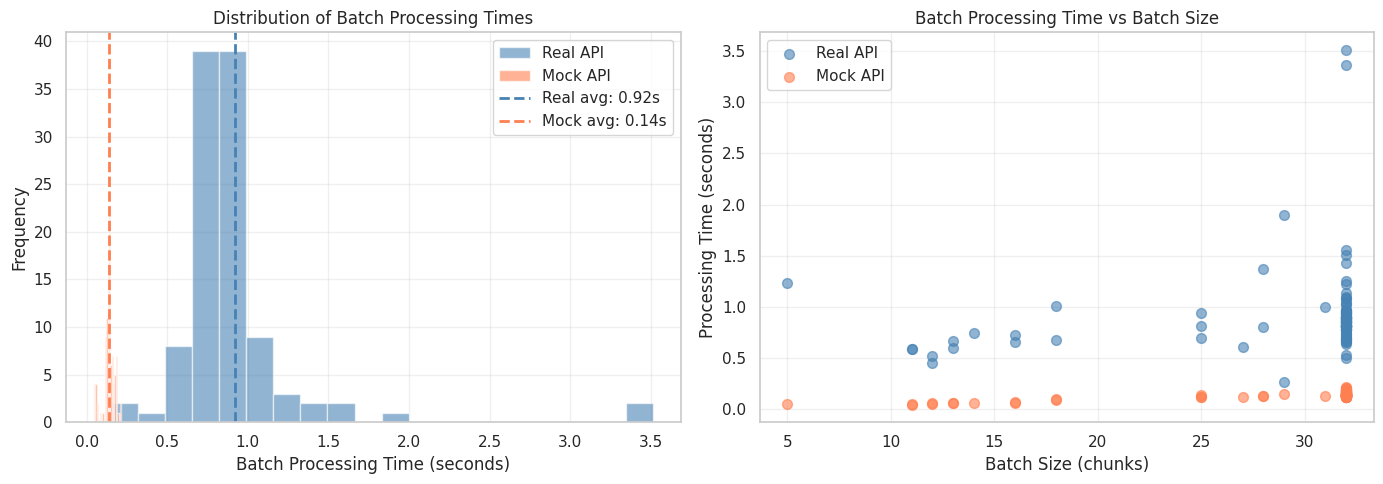

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of batch times
ax = axes[0]
ax.hist(test_1_data['seconds'], alpha=0.6, bins=20, label='Real API', color='steelblue')
ax.hist(test_2_data['seconds'], alpha=0.6, bins=20, label='Mock API', color='coral')
ax.axvline(stats_1['avg_time_per_batch'], color='steelblue', linestyle='--', linewidth=2, label=f'Real avg: {stats_1["avg_time_per_batch"]:.2f}s')
ax.axvline(stats_2['avg_time_per_batch'], color='coral', linestyle='--', linewidth=2, label=f'Mock avg: {stats_2["avg_time_per_batch"]:.2f}s')
ax.set_xlabel('Batch Processing Time (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Batch Processing Times')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Batch time vs batch size
ax = axes[1]
ax.scatter(test_1_data['batch_size'], test_1_data['seconds'], alpha=0.6, label='Real API', color='steelblue', s=50)
ax.scatter(test_2_data['batch_size'], test_2_data['seconds'], alpha=0.6, label='Mock API', color='coral', s=50)
ax.set_xlabel('Batch Size (chunks)')
ax.set_ylabel('Processing Time (seconds)')
ax.set_title('Batch Processing Time vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization: Time Breakdown

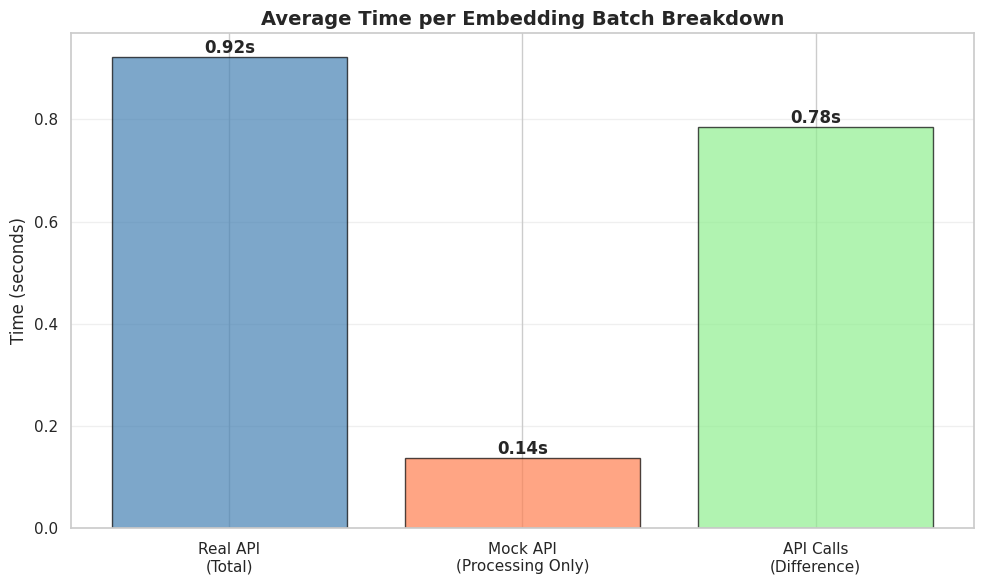


💡 Interpretation:
   - Each batch spends ~85.0% of time waiting for API calls
   - Each batch spends ~15.0% of time doing other work
   - API overhead per batch: 0.78s


In [92]:
# Create a bar chart showing time breakdown
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Real API\n(Total)', 'Mock API\n(Processing Only)', 'API Calls\n(Difference)']
values = [
    stats_1['avg_time_per_batch'],
    stats_2['avg_time_per_batch'],
    api_overhead_per_batch
]
colors = ['steelblue', 'coral', 'lightgreen']

bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Average Time per Embedding Batch Breakdown', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   - Each batch spends ~{api_proportion:.1f}% of time waiting for API calls")
print(f"   - Each batch spends ~{processing_proportion:.1f}% of time doing other work")
print(f"   - API overhead per batch: {api_overhead_per_batch:.2f}s")

## Concurrency Optimization Recommendations

Based on the analysis above, here are recommendations for tuning your Celery and LiteLLM settings:

In [93]:
# Calculate optimization recommendations
print("\n" + "="*70)
print("CONCURRENCY OPTIMIZATION RECOMMENDATIONS")
print("="*70)

print(f"\n📊 Current Performance Metrics:")
print(f"   - API time per batch: {api_overhead_per_batch:.2f}s ({api_proportion:.1f}% of total)")
print(f"   - Processing time per batch: {stats_2['avg_time_per_batch']:.2f}s ({processing_proportion:.1f}% of total)")
print(f"   - Average batch size: {stats_1['avg_batch_size']:.1f} chunks")

# Calculate throughput
batches_per_sec_real = 1 / stats_1['avg_time_per_batch'] if stats_1['avg_time_per_batch'] > 0 else 0
batches_per_sec_mock = 1 / stats_2['avg_time_per_batch'] if stats_2['avg_time_per_batch'] > 0 else 0

print(f"\n⚡ Throughput (single worker):")
print(f"   - With real API: {batches_per_sec_real:.2f} batches/sec")
print(f"   - With mock API: {batches_per_sec_mock:.2f} batches/sec")
print(f"   - Processing capacity: {batches_per_sec_mock:.2f} batches/sec (if API was instant)")

# Calculate optimal concurrency
# If workers spend X% of time waiting (idle), we can run 1/(1-X) concurrent workers
# Example: 96% waiting → 1/0.04 = 25 workers can share the same processing capacity
processing_fraction = processing_proportion / 100
optimal_concurrency_processing_bound = 1 / processing_fraction if processing_fraction > 0 else float('inf')

# Also consider wall-clock time speedup potential
# With concurrency=1, total time was X. With concurrency=N, time could be reduced by parallelizing API waits
wall_clock_speedup_potential = stats_1['total_duration'] / stats_2['total_duration'] if stats_2['total_duration'] > 0 else 1

print(f"\n🎯 Optimal Concurrency Settings:")
print(f"\n   Based on processing time ({processing_proportion:.1f}%):")
print(f"   - Each worker spends only {processing_proportion:.1f}% of time doing actual work")
print(f"   - Each worker is IDLE {api_proportion:.1f}% of time waiting for API responses")
print(f"   - You can run ~{optimal_concurrency_processing_bound:.0f} concurrent workers")
print(f"     without saturating your processing capacity")
print(f"     (While {optimal_concurrency_processing_bound-1:.0f} workers wait for API, 1 worker does real work)")

print(f"\n   Wall-clock time analysis:")
print(f"   - With concurrency=1: {stats_1['total_duration']:.1f}s total")
print(f"   - Theoretical minimum (all API parallel): {stats_2['total_duration']:.1f}s")
print(f"   - Speedup potential: {wall_clock_speedup_potential:.1f}x")

if api_proportion > 70:
    print(f"\n   ⚠️  API calls dominate processing time ({api_proportion:.1f}%)")
    print(f"      Higher concurrency will help saturate available processing capacity.")
    print(f"      Your workers are mostly idle waiting for API responses!")
elif api_proportion < 30:
    print(f"\n   ✅ Processing time dominates ({processing_proportion:.1f}%)")
    print(f"      Lower concurrency is sufficient - workers are CPU-bound.")
else:
    print(f"\n   ✅ Balanced mix of API and processing time")
    print(f"      Moderate concurrency recommended.")

# Calculate safe concurrency range
target_concurrency = int(optimal_concurrency_processing_bound * 0.7)  # Conservative: use 70% of theoretical max
max_concurrency = int(optimal_concurrency_processing_bound * 0.9)    # Aggressive: use 90% of theoretical max

print(f"\n📝 Recommendations:")
print(f"   1. Celery concurrency: {target_concurrency}-{max_concurrency} workers")
print(f"      Conservative: {target_concurrency} (70% of theoretical max)")
print(f"      Aggressive: {max_concurrency} (90% of theoretical max)")
print(f"      Theoretical maximum: {int(optimal_concurrency_processing_bound)} (100% utilization)")
print(f"\n   2. LiteLLM max_parallel_requests: {target_concurrency}-{max_concurrency}")
print(f"      Should match Celery concurrency")
print(f"      Each worker makes 1 API request at a time")
print(f"\n   3. Monitor for rate limiting:")
print(f"      - Watch for 429 errors in logs")
print(f"      - If rate limited, reduce max_parallel_requests")
print(f"      - Expected throughput: ~{batches_per_sec_real * target_concurrency:.1f} batches/sec with {target_concurrency} workers")

print(f"\n💡 Key Insights:")
print(f"   • With {target_concurrency} workers, you can process ~{int(target_concurrency * batches_per_sec_real)} batches/sec")
print(f"     = ~{int(target_concurrency * batches_per_sec_real * stats_1['avg_batch_size'])} chunks/sec")
print(f"   • This is {target_concurrency * batches_per_sec_real / batches_per_sec_real:.1f}x faster than single worker")
print(f"   • Workers will be ~{processing_proportion * target_concurrency:.0f}% utilized (doing actual work)")
print(f"   • The rest of the time, workers are waiting for API responses (which is fine!)")


CONCURRENCY OPTIMIZATION RECOMMENDATIONS

📊 Current Performance Metrics:
   - API time per batch: 0.78s (85.0% of total)
   - Processing time per batch: 0.14s (15.0% of total)
   - Average batch size: 29.5 chunks

⚡ Throughput (single worker):
   - With real API: 1.08 batches/sec
   - With mock API: 7.25 batches/sec
   - Processing capacity: 7.25 batches/sec (if API was instant)

🎯 Optimal Concurrency Settings:

   Based on processing time (15.0%):
   - Each worker spends only 15.0% of time doing actual work
   - Each worker is IDLE 85.0% of time waiting for API responses
   - You can run ~7 concurrent workers
     without saturating your processing capacity
     (While 6 workers wait for API, 1 worker does real work)

   Wall-clock time analysis:
   - With concurrency=1: 145.5s total
   - Theoretical minimum (all API parallel): 21.4s
   - Speedup potential: 6.8x

   ⚠️  API calls dominate processing time (85.0%)
      Higher concurrency will help saturate available processing capacit

## Update Measured Values

Update the configuration with actual measured values from this test run:

In [94]:
# Update measured values from test results
MEASURED_AVG_BATCH_TIME_WITH_API = avg_with_api_call
MEASURED_AVG_BATCH_SIZE = stats_1['avg_batch_size']
MEASURED_PROCESSING_FRACTION = processing_fraction

print("="*70)
print("UPDATED MEASURED VALUES")
print("="*70)
print(f"\nOld values → New values:")
print(f"   Avg batch time (with API): 2.30s → {MEASURED_AVG_BATCH_TIME_WITH_API:.2f}s")
print(f"   Avg batch size:            50.0 → {MEASURED_AVG_BATCH_SIZE:.1f} chunks")
print(f"   Processing fraction:       4.0% → {MEASURED_PROCESSING_FRACTION:.1%}")

# Recalculate optimal settings with measured values
optimal_updated = calculate_optimal_settings(
    AZURE_TPM, 
    AVG_TOKENS_PER_CHUNK,
    avg_batch_time_with_api=MEASURED_AVG_BATCH_TIME_WITH_API,
    avg_batch_size=MEASURED_AVG_BATCH_SIZE,
    processing_fraction=MEASURED_PROCESSING_FRACTION
)

print(f"\n🎯 Updated Optimal Settings:")
print(f"   TPM-limited concurrency:   {optimal['tpm_limited_concurrency']} → {optimal_updated['tpm_limited_concurrency']}")
print(f"   Processing-limited:        {optimal['processing_limited_concurrency']} → {optimal_updated['processing_limited_concurrency']}")
print(f"   Recommended concurrency:   {optimal['recommended_concurrency']} → {optimal_updated['recommended_concurrency']}")
print(f"   Safe concurrency (80%):    {optimal['safe_concurrency']} → {optimal_updated['safe_concurrency']}")

# Update the global optimal variable
optimal = optimal_updated

print(f"\n💡 These values will be used for future calculations in this session.")
print(f"   To persist them, copy these lines to the configuration cell:")
print(f"\n   MEASURED_AVG_BATCH_TIME_WITH_API = {MEASURED_AVG_BATCH_TIME_WITH_API:.2f}")
print(f"   MEASURED_AVG_BATCH_SIZE = {MEASURED_AVG_BATCH_SIZE:.1f}")
print(f"   MEASURED_PROCESSING_FRACTION = {MEASURED_PROCESSING_FRACTION:.4f}")

UPDATED MEASURED VALUES

Old values → New values:
   Avg batch time (with API): 2.30s → 0.92s
   Avg batch size:            50.0 → 29.5 chunks
   Processing fraction:       4.0% → 15.0%

🎯 Updated Optimal Settings:
   TPM-limited concurrency:   1 → 0
   Processing-limited:        20 → 6
   Recommended concurrency:   1 → 0
   Safe concurrency (80%):    0 → 0

💡 These values will be used for future calculations in this session.
   To persist them, copy these lines to the configuration cell:

   MEASURED_AVG_BATCH_TIME_WITH_API = 0.92
   MEASURED_AVG_BATCH_SIZE = 29.5
   MEASURED_PROCESSING_FRACTION = 0.1497


## Save Experiment Result

Save this test's results for comparison across experiments:

In [95]:
# Save the experiment result with real API test
config = {
    'azure_tpm': AZURE_TPM,
    'celery_concurrency': CELERY_CONCURRENCY,
    'litellm_max_parallel': LITELLM_MAX_PARALLEL,
    'num_docs': NUM_DOCS,
}

experiment_result = save_experiment_result(config, stats_1, test_1_data)

# Calculate efficiency safely
efficiency = 0
if CELERY_CONCURRENCY > 0:
    efficiency = (1 / CELERY_CONCURRENCY) * experiment_result['chunks_per_sec']

print("\n" + "="*70)
print("EXPERIMENT SAVED")
print("="*70)
print(f"Throughput: {experiment_result['chunks_per_sec']:.1f} chunks/sec")
print(f"Rate limited: {'YES ⚠️' if experiment_result['hit_rate_limit'] else 'NO ✓'}")
print(f"Efficiency: {efficiency:.1f} chunks/sec per worker")


✓ Experiment result saved to /workspace/django/tests/misc_non_pytest/concurrency_experiments.csv

EXPERIMENT SAVED
Throughput: 21.1 chunks/sec
Rate limited: YES ⚠️
Efficiency: 10.5 chunks/sec per worker


## Experiment History & Comparison

Compare results across all experiments to find the optimal settings:

In [96]:
# Load and display all experiments
experiments = load_experiment_history()

if len(experiments) == 0:
    print("No experiments recorded yet. Run a test first!")
else:
    print(f"\n{'='*70}")
    print(f"EXPERIMENT HISTORY ({len(experiments)} runs)")
    print(f"{'='*70}\n")
    
    # Calculate new columns
    # AVG_TOKENS_PER_CHUNK is defined in the config cell
    actual_tokens_processed = experiments['total_chunks'] * AVG_TOKENS_PER_CHUNK
    experiments['actual_tpm_k'] = (actual_tokens_processed / experiments['total_duration_sec']) * 60 / 1000

    # Display summary table
    display_cols = [
        'timestamp', 'celery_concurrency', 'litellm_max_parallel', 
        'total_chunks', 'total_duration_sec', 'chunks_per_sec',
        'hit_rate_limit', 'num_rate_limit_errors', 'actual_tpm_k'
    ]
    
    summary = experiments[display_cols].copy()
    summary['timestamp'] = pd.to_datetime(summary['timestamp']).dt.strftime('%Y-%m-%d %H:%M')
    summary = summary.sort_values('chunks_per_sec', ascending=False)
    
    print("Experiments ranked by throughput (best first):\n")
    display(summary)
    
    # Find best configuration
    best_no_rate_limit = experiments[~experiments['hit_rate_limit']].sort_values('chunks_per_sec', ascending=False)
    
    if len(best_no_rate_limit) > 0:
        best = best_no_rate_limit.iloc[0]
        print(f"\n🏆 BEST CONFIGURATION (no rate limiting):")
        print(f"   Celery concurrency:     {int(best['celery_concurrency'])}")
        print(f"   LiteLLM max_parallel:   {int(best['litellm_max_parallel'])}")
        print(f"   Throughput:             {best['chunks_per_sec']:.1f} chunks/sec")
        print(f"   Actual TPM:             {best['actual_tpm_k']:.0f}K tokens/min")
        print(f"   Total duration:         {best['total_duration_sec']:.1f}s for {int(best['total_chunks'])} chunks")
    else:
        print("\n⚠️  All experiments hit rate limits! Try reducing concurrency or increasing Azure TPM.")


EXPERIMENT HISTORY (9 runs)

Experiments ranked by throughput (best first):



,timestamp,celery_concurrency,litellm_max_parallel,total_chunks,total_duration_sec,chunks_per_sec,hit_rate_limit,num_rate_limit_errors,actual_tpm_k
7,2025-11-06 14:58,2,1,3065,141.808269,21.613690,True,7,972.616061
8,2025-11-06 15:06,2,1,3065,145.529272,21.061055,True,4,947.747472
3,2025-11-06 02:36,4,4,3065,163.795010,18.712414,True,27,842.058620
2,2025-11-06 02:31,4,1,3065,174.137245,17.601059,True,35,792.047673
0,2025-11-06 02:19,2,1,3065,175.173845,17.496904,True,5,787.360692
1,2025-11-06 02:25,1,1,3065,186.541583,16.430653,True,6,739.379382
6,2025-11-06 03:06,3,3,3065,194.053718,15.794596,True,7,710.756802
5,2025-11-06 02:57,2,1,3065,216.673424,14.145713,True,2,636.557071
4,2025-11-06 02:45,20,20,3083,289.945439,10.633035,True,20,478.486575



⚠️  All experiments hit rate limits! Try reducing concurrency or increasing Azure TPM.
